In [ ]:
# -*- coding: utf-8 -*-
"""Brain Tumor Classification with VGG19 (T4 GPU Optimized).ipynb

Automatically generated by Colab.
"""

# Mount Google Drive and install dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q torchmetrics matplotlib seaborn --no-cache-dir
!pip install -U torch torchvision --no-cache-dir

# Import libraries
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

# Enable Tensor Cores and mixed precision for T4 GPU
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('medium')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 263.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 253.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 237.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 279.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 170.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 169.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 184.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 256.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 240.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 227.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 239.0 MB/s eta 0:00:00
   ━━━

Using device: cuda (Tesla T4)
glioma: 1501 images
meningioma: 1501 images
pituitary: 1501 images
no_tumor: 1501 images

Dataset split:
Training samples: 4803
Testing samples: 1201


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 148MB/s]



Model architecture:
VGG19TumorModel(
  (vgg19): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): Re

...

Epoch 20:   0%|          | 0/151 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]


Epoch 20/20 Summary:
Train Loss: 0.0132 | Type Acc: 99.54% | Grade Acc: 119333.33%
Val Loss: 0.0248 | Type Acc: 98.83% | Grade Acc: 6953.85%

Training completed!


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]


Final Test Performance:
Type Accuracy: 99.50%
Grade Accuracy: 6969.23% (on tumor cases only)

Type Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.99      0.99       289
  meningioma       0.99      1.00      0.99       291
   pituitary       1.00      1.00      1.00       329
    no_tumor       0.99      0.99      0.99       292

    accuracy                           1.00      1201
   macro avg       0.99      0.99      0.99      1201
weighted avg       1.00      1.00      1.00      1201


Grade Classification Report (tumor cases only):
                                       precision    recall  f1-score   support

   Grade I (Least aggressive, benign)       1.00      1.00      1.00       620
Grade IV (Most aggressive, malignant)       1.00      0.99      0.99       289

                             accuracy                           1.00       909
                            macro avg       1.00      0.99      1.00       

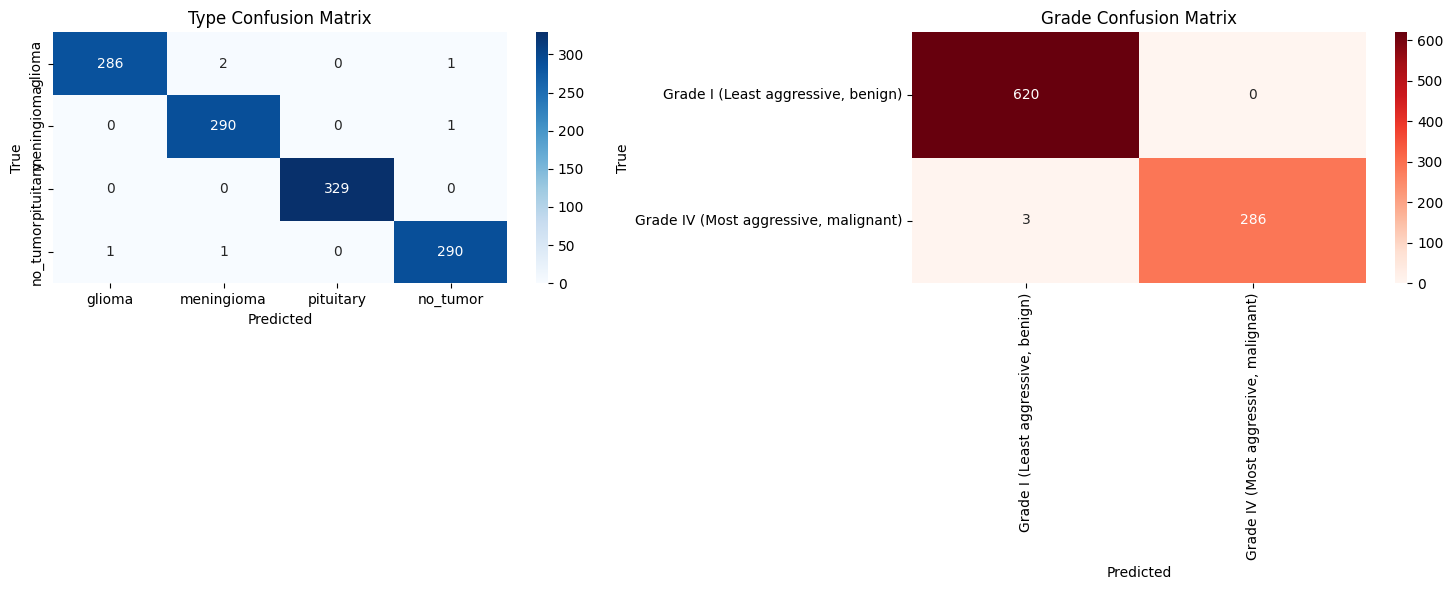

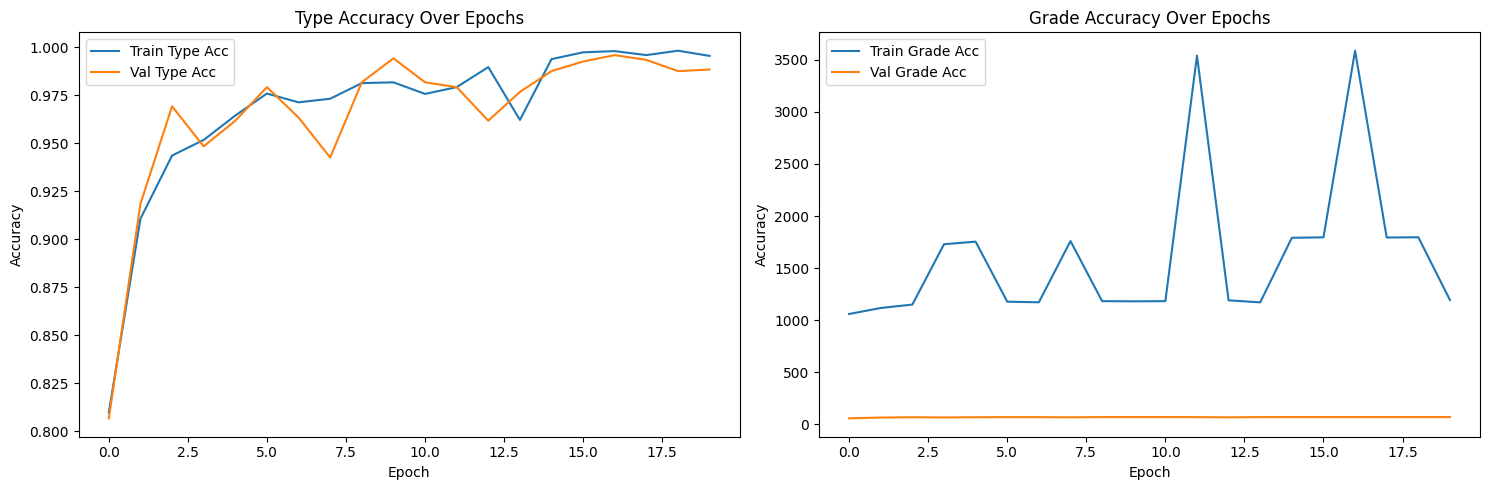

In [ ]:


# Device configuration (will use T4 GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Data path in Google Drive
data_dir = "/content/drive/MyDrive/Colab Notebooks/Augmented Data/Augmented"  # Update with your path
classes = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

# Verify dataset structure
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    if not os.path.exists(cls_path):
        raise FileNotFoundError(f"Directory {cls_path} not found")
    print(f"{cls}: {len(os.listdir(cls_path))} images")

# WHO Grading System Mapping
grade_mapping = {
    'glioma': 3,      # Grade IV (Glioblastoma)
    'meningioma': 0,  # Grade I
    'pituitary': 0,   # Grade I
    'no_tumor': -1    # Special case (no tumor)
}

grade_descriptions = [
    "Grade I (Least aggressive, benign)",
    "Grade II (Moderately aggressive)",
    "Grade III (Aggressive)",
    "Grade IV (Most aggressive, malignant)"
]

# Optimized Dataset Class with caching for T4 GPU
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        for class_idx, class_name in enumerate(classes):
            class_dir = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)
                self.samples.append({
                    'path': img_path,
                    'type': class_idx,
                    'grade': grade_mapping[class_name]
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            image = Image.open(sample['path']).convert('RGB')
            if self.transform:
                image = self.transform(image)

            return {
                'image': image,
                'type': sample['type'],
                'grade': sample['grade']
            }
        except Exception as e:
            print(f"Error loading {sample['path']}: {e}")
            return self[np.random.randint(0, len(self))]

# Optimized transformations for T4 GPU
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Standard size for VGG19
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = BrainTumorDataset(data_dir, transform=transform)

# Split dataset (80% train, 20% test)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Optimized DataLoader settings for T4 GPU
num_workers = 2 if torch.cuda.is_available() else 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,  # Optimal batch size for T4 memory
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

print(f"\nDataset split:")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

# VGG19 Model with multi-task output
class VGG19TumorModel(nn.Module):
    def __init__(self, num_types=4, num_grades=4):
        super().__init__()

        # Load pre-trained VGG19
        self.vgg19 = models.vgg19(pretrained=True)

        # Freeze early layers (optional, can be removed for full fine-tuning)
        for param in self.vgg19.features[:10].parameters():
            param.requires_grad = False

        # Replace classifier head
        self.features = self.vgg19.features
        self.avgpool = self.vgg19.avgpool

        # Feature extraction
        self.type_features = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

        self.grade_features = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

        # Classifiers
        self.type_classifier = nn.Linear(4096, num_types)
        self.grade_classifier = nn.Linear(4096, num_grades)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        # Feature extraction for both tasks
        type_feats = self.type_features(x)
        grade_feats = self.grade_features(x)

        # Classifiers
        type_logits = self.type_classifier(type_feats)
        grade_logits = self.grade_classifier(grade_feats)

        return type_logits, grade_logits

# Initialize model with mixed precision
model = VGG19TumorModel().to(device)
scaler = torch.cuda.amp.GradScaler()

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Loss functions
type_criterion = nn.CrossEntropyLoss()
grade_criterion = nn.CrossEntropyLoss(ignore_index=-1)

# Optimizer (AdamW with weight decay)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# Save directory
save_dir = "/content/drive/MyDrive/BrainTumorModels"
os.makedirs(save_dir, exist_ok=True)

# Training loop with mixed precision for T4 GPU
def train_epoch(epoch):
    model.train()
    running_loss = 0.0
    type_correct = 0
    grade_correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        images = batch['image'].to(device, non_blocking=True)
        types = batch['type'].to(device, non_blocking=True)
        grades = batch['grade'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision training
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            type_pred, grade_pred = model(images)
            loss_type = type_criterion(type_pred, types)
            loss_grade = grade_criterion(grade_pred, grades)
            loss = 0.6 * loss_type + 0.4 * loss_grade

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Metrics
        running_loss += loss.item() * images.size(0)
        _, type_predicted = torch.max(type_pred, 1)
        type_correct += (type_predicted == types).sum().item()

        grade_mask = grades != -1
        if grade_mask.any():
            _, grade_predicted = torch.max(grade_pred[grade_mask], 1)
            grade_correct += (grade_predicted == grades[grade_mask]).sum().item()

        total += images.size(0)
        pbar.set_postfix({
            'Loss': running_loss/total,
            'Type Acc': type_correct/total,
            'LR': optimizer.param_groups[0]['lr']
        })

    epoch_loss = running_loss / total
    type_acc = type_correct / total
    grade_acc = grade_correct / (grades != -1).sum().item() if (grades != -1).any() else 0

    return epoch_loss, type_acc, grade_acc

def evaluate():
    model.eval()
    running_loss = 0.0
    type_correct = 0
    grade_correct = 0
    total = 0

    all_type_preds = []
    all_type_labels = []
    all_grade_preds = []
    all_grade_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            images = batch['image'].to(device, non_blocking=True)
            types = batch['type'].to(device, non_blocking=True)
            grades = batch['grade'].to(device, non_blocking=True)

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                type_pred, grade_pred = model(images)
                loss_type = type_criterion(type_pred, types)
                loss_grade = grade_criterion(grade_pred, grades)
                loss = 0.6 * loss_type + 0.4 * loss_grade

            running_loss += loss.item() * images.size(0)
            _, type_predicted = torch.max(type_pred, 1)
            type_correct += (type_predicted == types).sum().item()

            grade_mask = grades != -1
            if grade_mask.any():
                _, grade_predicted = torch.max(grade_pred[grade_mask], 1)
                grade_correct += (grade_predicted == grades[grade_mask]).sum().item()

            total += images.size(0)

            all_type_preds.extend(type_predicted.cpu().numpy())
            all_type_labels.extend(types.cpu().numpy())
            if grade_mask.any():
                all_grade_preds.extend(grade_predicted.cpu().numpy())
                all_grade_labels.extend(grades[grade_mask].cpu().numpy())

    avg_loss = running_loss / total
    type_acc = type_correct / total
    grade_acc = grade_correct / (grades != -1).sum().item() if (grades != -1).any() else 0

    return avg_loss, type_acc, grade_acc, all_type_preds, all_type_labels, all_grade_preds, all_grade_labels

# Training parameters
num_epochs = 20  # Reduced epochs for Colab demo
best_acc = 0.0

train_losses = []
val_losses = []
train_type_accs = []
val_type_accs = []
train_grade_accs = []
val_grade_accs = []

# Training loop
print("\nStarting training...")
for epoch in range(num_epochs):
    train_loss, train_type_acc, train_grade_acc = train_epoch(epoch)
    val_loss, val_type_acc, val_grade_acc, _, _, _, _ = evaluate()
    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_type_accs.append(train_type_acc)
    val_type_accs.append(val_type_acc)
    train_grade_accs.append(train_grade_acc)
    val_grade_accs.append(val_grade_acc)

    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Train Loss: {train_loss:.4f} | Type Acc: {train_type_acc:.2%} | Grade Acc: {train_grade_acc:.2%}")
    print(f"Val Loss: {val_loss:.4f} | Type Acc: {val_type_acc:.2%} | Grade Acc: {val_grade_acc:.2%}")

    # Save best model
    if val_type_acc > best_acc:
        best_acc = val_type_acc
        model_path = os.path.join(save_dir, "best_vgg19_model_t4.pth")
        torch.save(model.state_dict(), model_path)
        print(f"Saved new best model to {model_path}")

print("\nTraining completed!")

# Load best model
model.load_state_dict(torch.load(os.path.join(save_dir, "best_vgg19_model_t4.pth")))
model.eval()

# Final evaluation
test_loss, test_type_acc, test_grade_acc, type_preds, type_labels, grade_preds, grade_labels = evaluate()
print(f"\nFinal Test Performance:")
print(f"Type Accuracy: {test_type_acc:.2%}")
print(f"Grade Accuracy: {test_grade_acc:.2%} (on tumor cases only)")

# Classification reports
print("\nType Classification Report:")
print(classification_report(type_labels, type_preds, target_names=classes))

print("\nGrade Classification Report (tumor cases only):")
if len(grade_labels) > 0:
    unique_grades = np.unique(grade_labels)
    print(classification_report(
        grade_labels,
        grade_preds,
        labels=unique_grades,
        target_names=[grade_descriptions[i] for i in unique_grades]
    ))

# Confusion matrices
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
cm_type = confusion_matrix(type_labels, type_preds)
sns.heatmap(cm_type, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Type Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

if len(grade_labels) > 0:
    plt.subplot(1, 2, 2)
    cm_grade = confusion_matrix(grade_labels, grade_preds, labels=unique_grades)
    sns.heatmap(cm_grade, annot=True, fmt='d', cmap='Reds',
                xticklabels=[grade_descriptions[i] for i in unique_grades],
                yticklabels=[grade_descriptions[i] for i in unique_grades])
    plt.title('Grade Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')

plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_type_accs, label='Train Type Acc')
plt.plot(val_type_accs, label='Val Type Acc')
plt.title('Type Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_grade_accs, label='Train Grade Acc')
plt.plot(val_grade_accs, label='Val Grade Acc')
plt.title('Grade Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Prediction function for custom images
def predict_tumor(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
    except:
        print(f"Error loading image: {image_path}")
        return None

    with torch.no_grad():
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            type_logits, grade_logits = model(img_tensor)

    type_probs = torch.softmax(type_logits, dim=1)[0]
    grade_probs = torch.softmax(grade_logits, dim=1)[0]

    type_idx = torch.argmax(type_probs).item()
    tumor_type = classes[type_idx]
    type_conf = float(type_probs[type_idx])

    result = {
        'tumor_detected': tumor_type != 'no_tumor',
        'type': tumor_type,
        'type_confidence': type_conf,
        'grade': None,
        'grade_confidence': None,
        'characteristics': []
    }

    if result['tumor_detected']:
        grade_idx = torch.argmax(grade_probs).item()
        result.update({
            'grade': grade_descriptions[grade_idx],
            'grade_confidence': float(grade_probs[grade_idx]),
            'characteristics': [
                "Diffuse growth pattern" if tumor_type == 'glioma' else "Well-circumscribed",
                "High recurrence risk" if grade_idx >= 2 else "Low recurrence risk",
                "Aggressive" if grade_idx >= 2 else "Less aggressive"
            ]
        })

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Input Image\n{os.path.basename(image_path)}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    info_text = f"Type: {tumor_type} ({type_conf:.1%})"
    if result['tumor_detected']:
        info_text += f"\nGrade: {result['grade']}\nCharacteristics:\n- " + "\n- ".join(result['characteristics'])
    plt.text(0.1, 0.5, info_text, fontsize=12, va='center')
    plt.axis('off')
    plt.show()

    return result

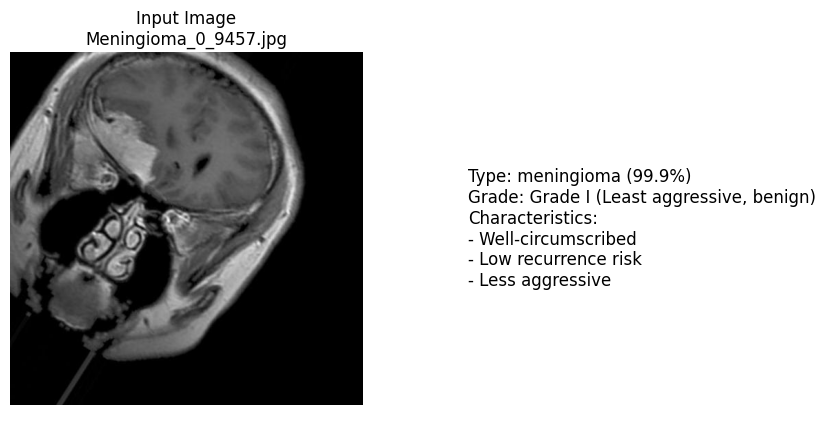


Prediction Result:
      tumor_detected: True
                type: meningioma
     type_confidence: 0.99853515625
               grade: Grade I (Least aggressive, benign)
    grade_confidence: 0.998046875
     characteristics: ['Well-circumscribed', 'Low recurrence risk', 'Less aggressive']


In [ ]:

# Example prediction
sample_image ="/content/drive/MyDrive/Colab Notebooks/Augmented Data/Augmented/meningioma/Meningioma_0_9457.jpg"  # Replace with your image
prediction = predict_tumor(sample_image)

if prediction:
    print("\nPrediction Result:")
    for k, v in prediction.items():
        print(f"{k:>20}: {v}")